In [ ]:
import pandas as pd

In [ ]:
df= pd.read_csv("https://raw.githubusercontent.com/guilhermeonrails/data-jobs/refs/heads/main/salaries.csv")

In [ ]:
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2025.0,SE,FT,Solutions Engineer,214000,USD,214000,US,100,US,M
1,2025.0,SE,FT,Solutions Engineer,136000,USD,136000,US,100,US,M
2,2025.0,MI,FT,Data Engineer,158800,USD,158800,AU,0,AU,M
3,2025.0,MI,FT,Data Engineer,139200,USD,139200,AU,0,AU,M
4,2025.0,EN,FT,Data Engineer,90000,USD,90000,US,0,US,M


In [ ]:
# Dicionário de renomeação
novos_nomes = {
    'work_year': 'ano',
    'experience_level': 'senioridade',
    'employment_type': 'contrato',
    'job_title': 'cargo',
    'salary': 'salario',
    'salary_currency': 'moeda',
    'salary_in_usd': 'usd',
    'employee_residence': 'residencia',
    'remote_ratio': 'remoto',
    'company_location': 'empresa',
    'company_size': 'tamanho_empresa'
}

# Aplicando renomeação
df.rename(columns=novos_nomes, inplace=True)

# Verificando resultado
df.head()


,ano,senioridade,contrato,cargo,salario,moeda,usd,residencia,remoto,empresa,tamanho_empresa
0,2025.0,SE,FT,Solutions Engineer,214000,USD,214000,US,100,US,M
1,2025.0,SE,FT,Solutions Engineer,136000,USD,136000,US,100,US,M
2,2025.0,MI,FT,Data Engineer,158800,USD,158800,AU,0,AU,M
3,2025.0,MI,FT,Data Engineer,139200,USD,139200,AU,0,AU,M
4,2025.0,EN,FT,Data Engineer,90000,USD,90000,US,0,US,M


In [ ]:
# O método .value_counts() serve para contar quantas vezes cada valor único aparece em uma coluna.
df['senioridade'].value_counts()


,count
senioridade,
SE,77241
MI,40465
EN,12443
EX,3200


In [ ]:
senioridade = {
    'SE': 'senior',
    'MI': 'pleno',
    'EN': 'junior',
    'EX': 'executivo'
}
df['senioridade'] = df['senioridade'].replace(senioridade)
df['senioridade'].value_counts()


,count
senioridade,
senior,77241
pleno,40465
junior,12443
executivo,3200


In [ ]:
contrato = {
    'FT': 'integral',
    'PT': 'parcial',
    'CT': 'contrato',
    'FL': 'freelancer'
}
df['contrato'] = df['contrato'].replace(contrato)
df['contrato'].value_counts()


,count
contrato,
integral,132563
contrato,394
parcial,376
freelancer,16


In [ ]:
tamanho_empresa = {
    'L': 'grande',
    'S': 'pequena',
    'M':	'media'

}
df['tamanho_empresa'] = df['tamanho_empresa'].replace(tamanho_empresa)
df['tamanho_empresa'].value_counts()


,count
tamanho_empresa,
media,129561
grande,3574
pequena,214


In [ ]:
mapa_trabalho = {
    0: 'presencial',
    100: 'remoto',
    50: 'hibrido'
}

df['remoto'] = df['remoto'].replace(mapa_trabalho)
df['remoto'].value_counts()



,count
remoto,
presencial,105312
remoto,27718
hibrido,319


In [ ]:
df.describe(include='object')

,senioridade,contrato,cargo,moeda,residencia,remoto,empresa,tamanho_empresa
count,133349,133349,133349,133349,133349,133349,133349,133349
unique,4,4,390,26,102,3,95,3
top,senior,integral,Data Scientist,USD,US,presencial,US,media
freq,77241,132563,17314,126140,119579,105312,119641,129561


In [ ]:
df.isnull()

,ano,senioridade,contrato,cargo,salario,moeda,usd,residencia,remoto,empresa,tamanho_empresa
0,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
133344,False,False,False,False,False,False,False,False,False,False,False
133345,False,False,False,False,False,False,False,False,False,False,False
133346,False,False,False,False,False,False,False,False,False,False,False
133347,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
df.isnull().sum()

,0
ano,10
senioridade,0
contrato,0
cargo,0
salario,0
moeda,0
usd,0
residencia,0
remoto,0
empresa,0


In [ ]:
df["ano"].unique()

array([2025.,   nan, 2024., 2022., 2023., 2020., 2021.])

In [ ]:
df[df.isnull().any(axis=1)]

,ano,senioridade,contrato,cargo,salario,moeda,usd,residencia,remoto,empresa,tamanho_empresa
5588,NaN,senior,integral,Product Manager,184500,USD,184500,US,presencial,US,media
59692,NaN,pleno,integral,Engineer,110000,USD,110000,DE,presencial,DE,media
59710,NaN,junior,integral,Data Scientist,208800,USD,208800,US,presencial,US,media
59759,NaN,senior,integral,Software Engineer,135000,USD,135000,US,presencial,US,media
59789,NaN,senior,integral,Engineer,112000,USD,112000,US,presencial,US,media
131000,NaN,senior,integral,Machine Learning Engineer,163800,USD,163800,US,presencial,US,media
131006,NaN,senior,integral,Data Analytics Manager,204500,USD,204500,US,presencial,US,media
133054,NaN,junior,integral,Data Scientist,40000,USD,40000,JP,remoto,MY,grande
133281,NaN,pleno,integral,Machine Learning Engineer,180000,PLN,46597,PL,remoto,PL,grande
133317,NaN,pleno,integral,Data Scientist,130000,USD,130000,US,hibrido,US,grande


In [ ]:
import numpy as np
#Criando um dataframe para exemplificar uma forma de preencher campos nulos.
df_salarios = pd.DataFrame({
       'nome': ["ana", "Bruno","Carlos", "Daniele","Val"],
       'salario':[4000, np.nan ,5000, np.nan, 100000]
                            })
#Cria uma coluna e depois calcula a média e arredonda e substitui ela nos lugares nulos .
df_salarios['salario_media'] = df_salarios['salario'].fillna(df_salarios['salario'].mean().round(2))
#Cria uma coluna e Calcula a mediana e coloca ela nos lugares nulos.
df_salarios['salario_mediana'] = df_salarios['salario'].fillna(df_salarios['salario'].median())
df_salarios.head()

,nome,salario,salario_media,salario_mediana
0,ana,4000.0,4000.00,4000.0
1,Bruno,NaN,36333.33,5000.0
2,Carlos,5000.0,5000.00,5000.0
3,Daniele,NaN,36333.33,5000.0
4,Val,100000.0,100000.00,100000.0


In [ ]:
df_temperatura = pd.DataFrame ({
    "Dia":["Segunda", "Terça", "Quarta", "Quinta", "Sexta"],
    "Temperatura": [30, np.nan, np.nan, 28, 27]
})

df_temperatura["Preenchido_ffill"] = df_temperatura['Temperatura'].ffill()
df_temperatura

,Dia,Temperatura,Preenchido_ffill
0,Segunda,30.0,30.0
1,Terça,NaN,30.0
2,Quarta,NaN,30.0
3,Quinta,28.0,28.0
4,Sexta,27.0,27.0


In [ ]:
df_temperatura = pd.DataFrame ({
    "Dia":["Segunda", "Terça", "Quarta", "Quinta", "Sexta"],
    "Temperatura": [30, np.nan, np.nan, 28, 27]
})

df_temperatura["Preenchido_bfill"] = df_temperatura['Temperatura'].bfill()
df_temperatura

,Dia,Temperatura,Preenchido_bfill
0,Segunda,30.0,30.0
1,Terça,NaN,28.0
2,Quarta,NaN,28.0
3,Quinta,28.0,28.0
4,Sexta,27.0,27.0


In [ ]:
df_cidade= pd.DataFrame({
    "nome": ["ana", "Bruno","Carlos", "Daniele","Val"],
    "cidade": ['São Paulo', np.nan, 'Curitiba', np.nan, "Belém"]
})

df_cidade['cidade_preenchida']= df_cidade['cidade'].fillna("Não informado")
df_cidade

,nome,cidade,cidade_preenchida
0,ana,São Paulo,São Paulo
1,Bruno,NaN,Não informado
2,Carlos,Curitiba,Curitiba
3,Daniele,NaN,Não informado
4,Val,Belém,Belém


In [ ]:
df_limpo= df.dropna()
df_limpo.isnull().sum()

,0
ano,0
senioridade,0
contrato,0
cargo,0
salario,0
moeda,0
usd,0
residencia,0
remoto,0
empresa,0


In [ ]:
df_limpo.head()

,ano,senioridade,contrato,cargo,salario,moeda,usd,residencia,remoto,empresa,tamanho_empresa
0,2025.0,senior,integral,Solutions Engineer,214000,USD,214000,US,remoto,US,media
1,2025.0,senior,integral,Solutions Engineer,136000,USD,136000,US,remoto,US,media
2,2025.0,pleno,integral,Data Engineer,158800,USD,158800,AU,presencial,AU,media
3,2025.0,pleno,integral,Data Engineer,139200,USD,139200,AU,presencial,AU,media
4,2025.0,junior,integral,Data Engineer,90000,USD,90000,US,presencial,US,media


In [ ]:
df_limpo.info()

<class 'pandas.core.frame.DataFrame'>
Index: 133339 entries, 0 to 133348
Data columns (total 11 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   ano              133339 non-null  float64
 1   senioridade      133339 non-null  object 
 2   contrato         133339 non-null  object 
 3   cargo            133339 non-null  object 
 4   salario          133339 non-null  int64  
 5   moeda            133339 non-null  object 
 6   usd              133339 non-null  int64  
 7   residencia       133339 non-null  object 
 8   remoto           133339 non-null  object 
 9   empresa          133339 non-null  object 
 10  tamanho_empresa  133339 non-null  object 
dtypes: float64(1), int64(2), object(8)
memory usage: 12.2+ MB


In [ ]:
df_limpo=df_limpo.assign(ano = df_limpo['ano'].astype("int64"))

In [ ]:
df_limpo.head()

,ano,senioridade,contrato,cargo,salario,moeda,usd,residencia,remoto,empresa,tamanho_empresa
0,2025,senior,integral,Solutions Engineer,214000,USD,214000,US,remoto,US,media
1,2025,senior,integral,Solutions Engineer,136000,USD,136000,US,remoto,US,media
2,2025,pleno,integral,Data Engineer,158800,USD,158800,AU,presencial,AU,media
3,2025,pleno,integral,Data Engineer,139200,USD,139200,AU,presencial,AU,media
4,2025,junior,integral,Data Engineer,90000,USD,90000,US,presencial,US,media


<Axes: title={'center': 'Distribuição de Senioridade'}, xlabel='senioridade'>

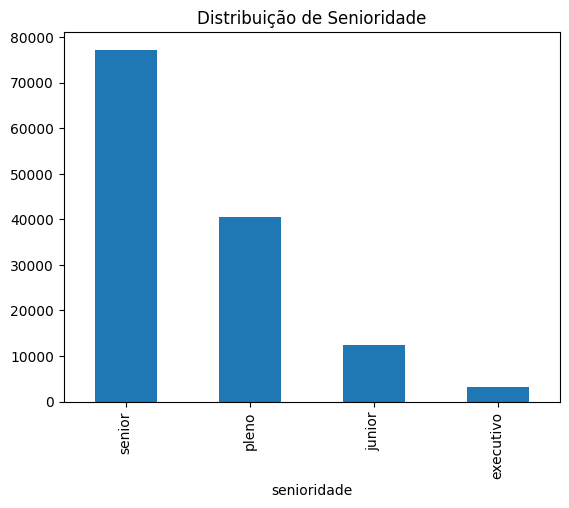

In [ ]:
df_limpo["senioridade"].value_counts().plot(kind = "bar",title="Distribuição de Senioridade")

In [ ]:
import seaborn as sns

<Axes: xlabel='senioridade', ylabel='usd'>

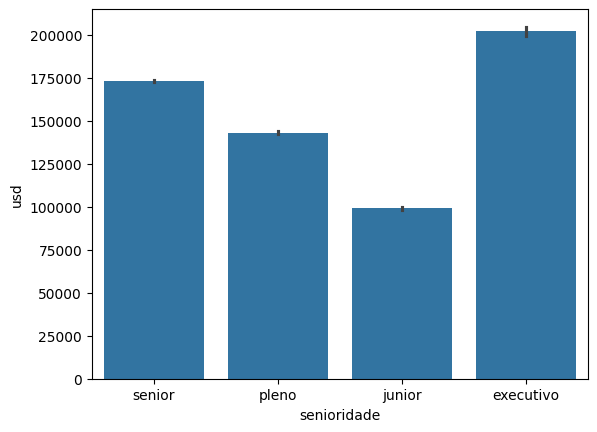

In [ ]:
sns.barplot(data=df_limpo, x="senioridade",y = "usd")

In [ ]:
import matplotlib.pyplot as plt


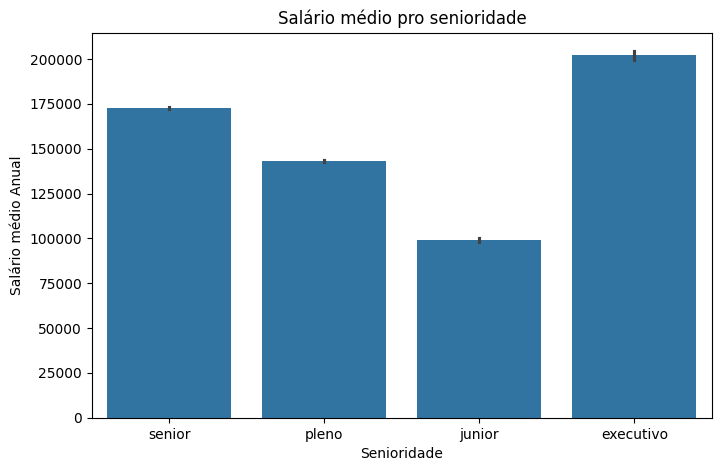

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(data=df_limpo, x="senioridade",y = "usd")
plt.title('Salário médio pro senioridade')
plt.xlabel('Senioridade')
plt.ylabel('Salário médio Anual')
plt.show()

In [ ]:
df_limpo.groupby('senioridade')['usd'].mean().sort_values(ascending= False)

,usd
senioridade,
executivo,202027.667813
senior,172850.838301
pleno,143044.845979
junior,99034.963267


In [ ]:
ordem=df_limpo.groupby('senioridade')['usd'].mean().sort_values(ascending= False).index
ordem

Index(['executivo', 'senior', 'pleno', 'junior'], dtype='object', name='senioridade')

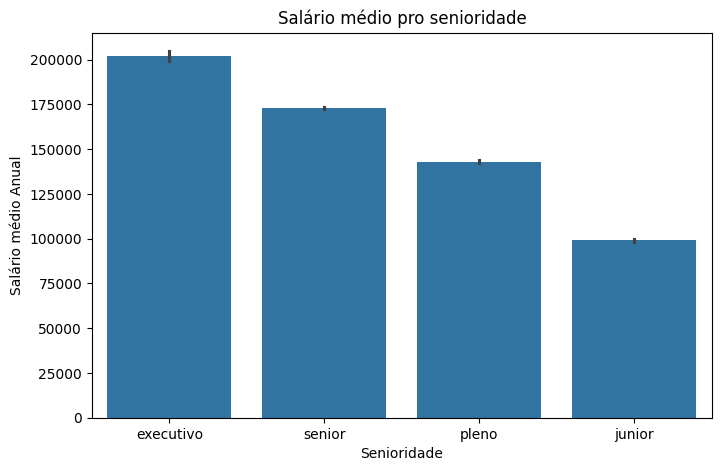

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(data=df_limpo, x="senioridade",y = "usd",order= ordem)
plt.title('Salário médio pro senioridade')
plt.xlabel('Senioridade')
plt.ylabel('Salário médio Anual')
plt.show()

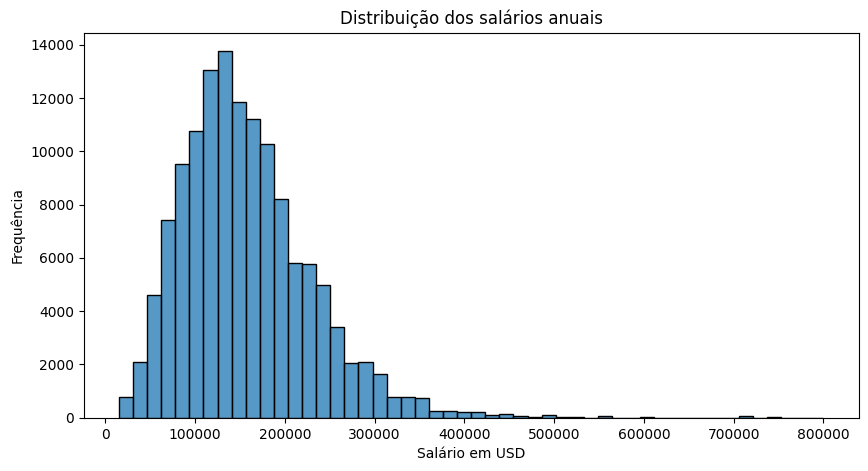

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(df_limpo["usd"],bins = 50 ,kde= False)
plt.title('Distribuição dos salários anuais')
plt.xlabel('Salário em USD')
plt.ylabel('Frequência')
plt.show()

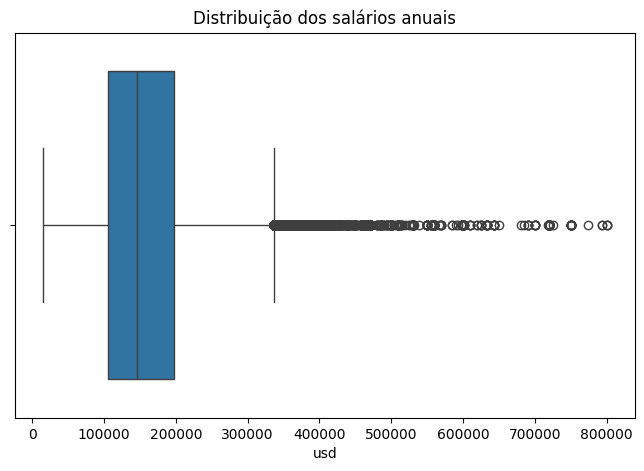

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df_limpo["usd"])
plt.title('Distribuição dos salários anuais')
plt.xlabel('usd')
plt.show()

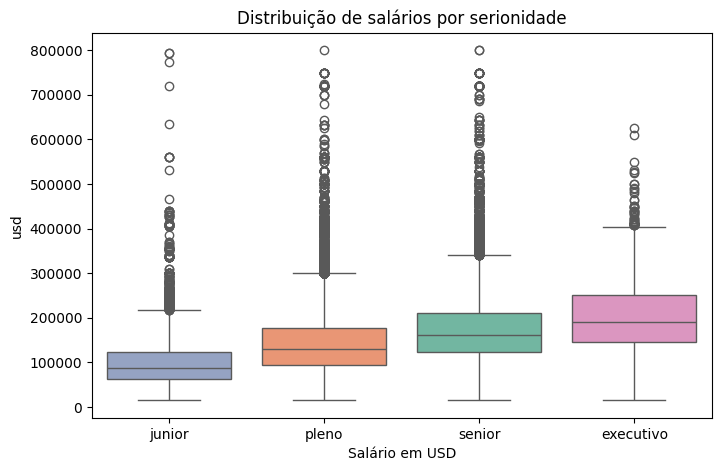

In [ ]:
ordem_senioridade=["junior", "pleno", "senior","executivo"]
plt.figure(figsize=(8,5))
sns.boxplot(x="senioridade", y="usd", data=df_limpo, order= ordem_senioridade, palette="Set2", hue= "senioridade")
plt.title("Distribuição de salários por serionidade")
plt.xlabel("Salário em USD")
plt.show()

In [ ]:
import plotly.express as px

In [ ]:
remoto_contagem=df_limpo["remoto"].value_counts().reset_index()
remoto_contagem.columns=["tipo_trabalho","quantidade"]
fig = px.pie (remoto_contagem,
             names="tipo_trabalho",
             values="quantidade",
             title='Proporção dos tipos de trabalho'
             )
fig.show()

In [ ]:
remoto_contagem=df_limpo["remoto"].value_counts().reset_index()
remoto_contagem.columns=["tipo_trabalho","quantidade"]
fig = px.pie (remoto_contagem,
             names="tipo_trabalho",
             values="quantidade",
              hole=0.5,
             title='Proporção dos tipos de trabalho'
             )
fig.show()

In [ ]:
remoto_contagem=df_limpo["remoto"].value_counts().reset_index()
remoto_contagem.columns=["tipo_trabalho","quantidade"]
fig = px.pie (remoto_contagem,
             names="tipo_trabalho",
             values="quantidade",
              hole=0.5,
             title='Proporção dos tipos de trabalho'
             )
fig.update_traces(textinfo="percent+label")
fig.show()

In [ ]:
df_limpo.head()

,ano,senioridade,contrato,cargo,salario,moeda,usd,residencia,remoto,empresa,tamanho_empresa
0,2025,senior,integral,Solutions Engineer,214000,USD,214000,US,remoto,US,media
1,2025,senior,integral,Solutions Engineer,136000,USD,136000,US,remoto,US,media
2,2025,pleno,integral,Data Engineer,158800,USD,158800,AU,presencial,AU,media
3,2025,pleno,integral,Data Engineer,139200,USD,139200,AU,presencial,AU,media
4,2025,junior,integral,Data Engineer,90000,USD,90000,US,presencial,US,media


In [ ]:
#Biblioteca conversão SIGLA DE PAISES DE DUAS LETRAS PARA TRES, POIS O GRAFICO DE MAPA SÓ ACEITA A SIGA DOS PAISES COM TRES LETRAS
!pip install pycountry

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 53.9 MB/s eta 0:00:00


In [ ]:
import pycountry

In [ ]:
df_limpo.head()

,ano,senioridade,contrato,cargo,salario,moeda,usd,residencia,remoto,empresa,tamanho_empresa
0,2025,senior,integral,Solutions Engineer,214000,USD,214000,US,remoto,US,media
1,2025,senior,integral,Solutions Engineer,136000,USD,136000,US,remoto,US,media
2,2025,pleno,integral,Data Engineer,158800,USD,158800,AU,presencial,AU,media
3,2025,pleno,integral,Data Engineer,139200,USD,139200,AU,presencial,AU,media
4,2025,junior,integral,Data Engineer,90000,USD,90000,US,presencial,US,media


In [ ]:
def get_iso3(country):
    try:
        # Try to get by alpha_2 code first
        return pycountry.countries.get(alpha_2=country).alpha_3
    except:
        try:
            # If not found by alpha_2, try to get by name
            return pycountry.countries.get(name=country).alpha_3
        except:
            # If still not found, return None or a placeholder
            return None

df_limpo['residencia_iso'] = df_limpo['residencia'].apply(get_iso3)

# Check if there are any remaining unmatched countries
unmatched_countries_after_fix = df_limpo[df_limpo['residencia_iso'].isnull()]['residencia'].unique()

if len(unmatched_countries_after_fix) > 0:
    print("Siglas de países ainda não encontradas:")
    print(unmatched_countries_after_fix)
else:
    print("Todas as siglas de países foram convertidas com sucesso!")

display(df_limpo.head())

Siglas de países ainda não encontradas:
['XK']


,ano,senioridade,contrato,cargo,salario,moeda,usd,residencia,remoto,empresa,tamanho_empresa,residencia_iso
0,2025,senior,integral,Solutions Engineer,214000,USD,214000,US,remoto,US,media,USA
1,2025,senior,integral,Solutions Engineer,136000,USD,136000,US,remoto,US,media,USA
2,2025,pleno,integral,Data Engineer,158800,USD,158800,AU,presencial,AU,media,AUS
3,2025,pleno,integral,Data Engineer,139200,USD,139200,AU,presencial,AU,media,AUS
4,2025,junior,integral,Data Engineer,90000,USD,90000,US,presencial,US,media,USA


In [ ]:
df_data_scientist = df_limpo[df_limpo['cargo'] == 'Data Scientist']
media_salario_data_scientist_por_pais = df_data_scientist.groupby('residencia_iso')['usd'].mean().reset_index()

fig = px.choropleth(media_salario_data_scientist_por_pais,
                    locations="residencia_iso",
                    color="usd",
                    hover_name="residencia_iso", # You can change this to a country name if you have it
                    color_continuous_scale=["red", "orange", "green"], # Red to Green color scale
                    title="Média Salarial Anual para Data Scientist por País")
fig.show()

In [62]:
#Salvando as alterações em um csv
df_limpo.to_csv("Imersao_alura", index=False )

In [63]:
#Salvando as alterações em um csv
df_limpo.to_csv("Imersao_alura.csv", index=False )

# Listar arquivos no diretório atual para verificar se o arquivo foi salvo
!ls

Imersao_alura  Imersao_alura.csv  sample_data
